In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

In [2]:
from impact import Impact

from distgen import Generator

import numpy as np

import os 

ROOT = os.environ['LCLS_LATTICE']

In [3]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (8,4)

# cu_inj Impact-T

In [4]:
ifile = os.path.join(ROOT, 'impact/models/cu_inj/ImpactT.yaml')
gfile = os.path.join(ROOT, 'distgen/models/cu_inj/distgen.yaml')
assert os.path.exists(ifile)
assert os.path.exists(gfile)


In [5]:
I = Impact.from_yaml(ifile)

In [6]:
I.track1()

<ParticleGroup with 1 particles at 0x7f8969f8caf0>

here Figure(1152x648) <class 'matplotlib.figure.Figure'>


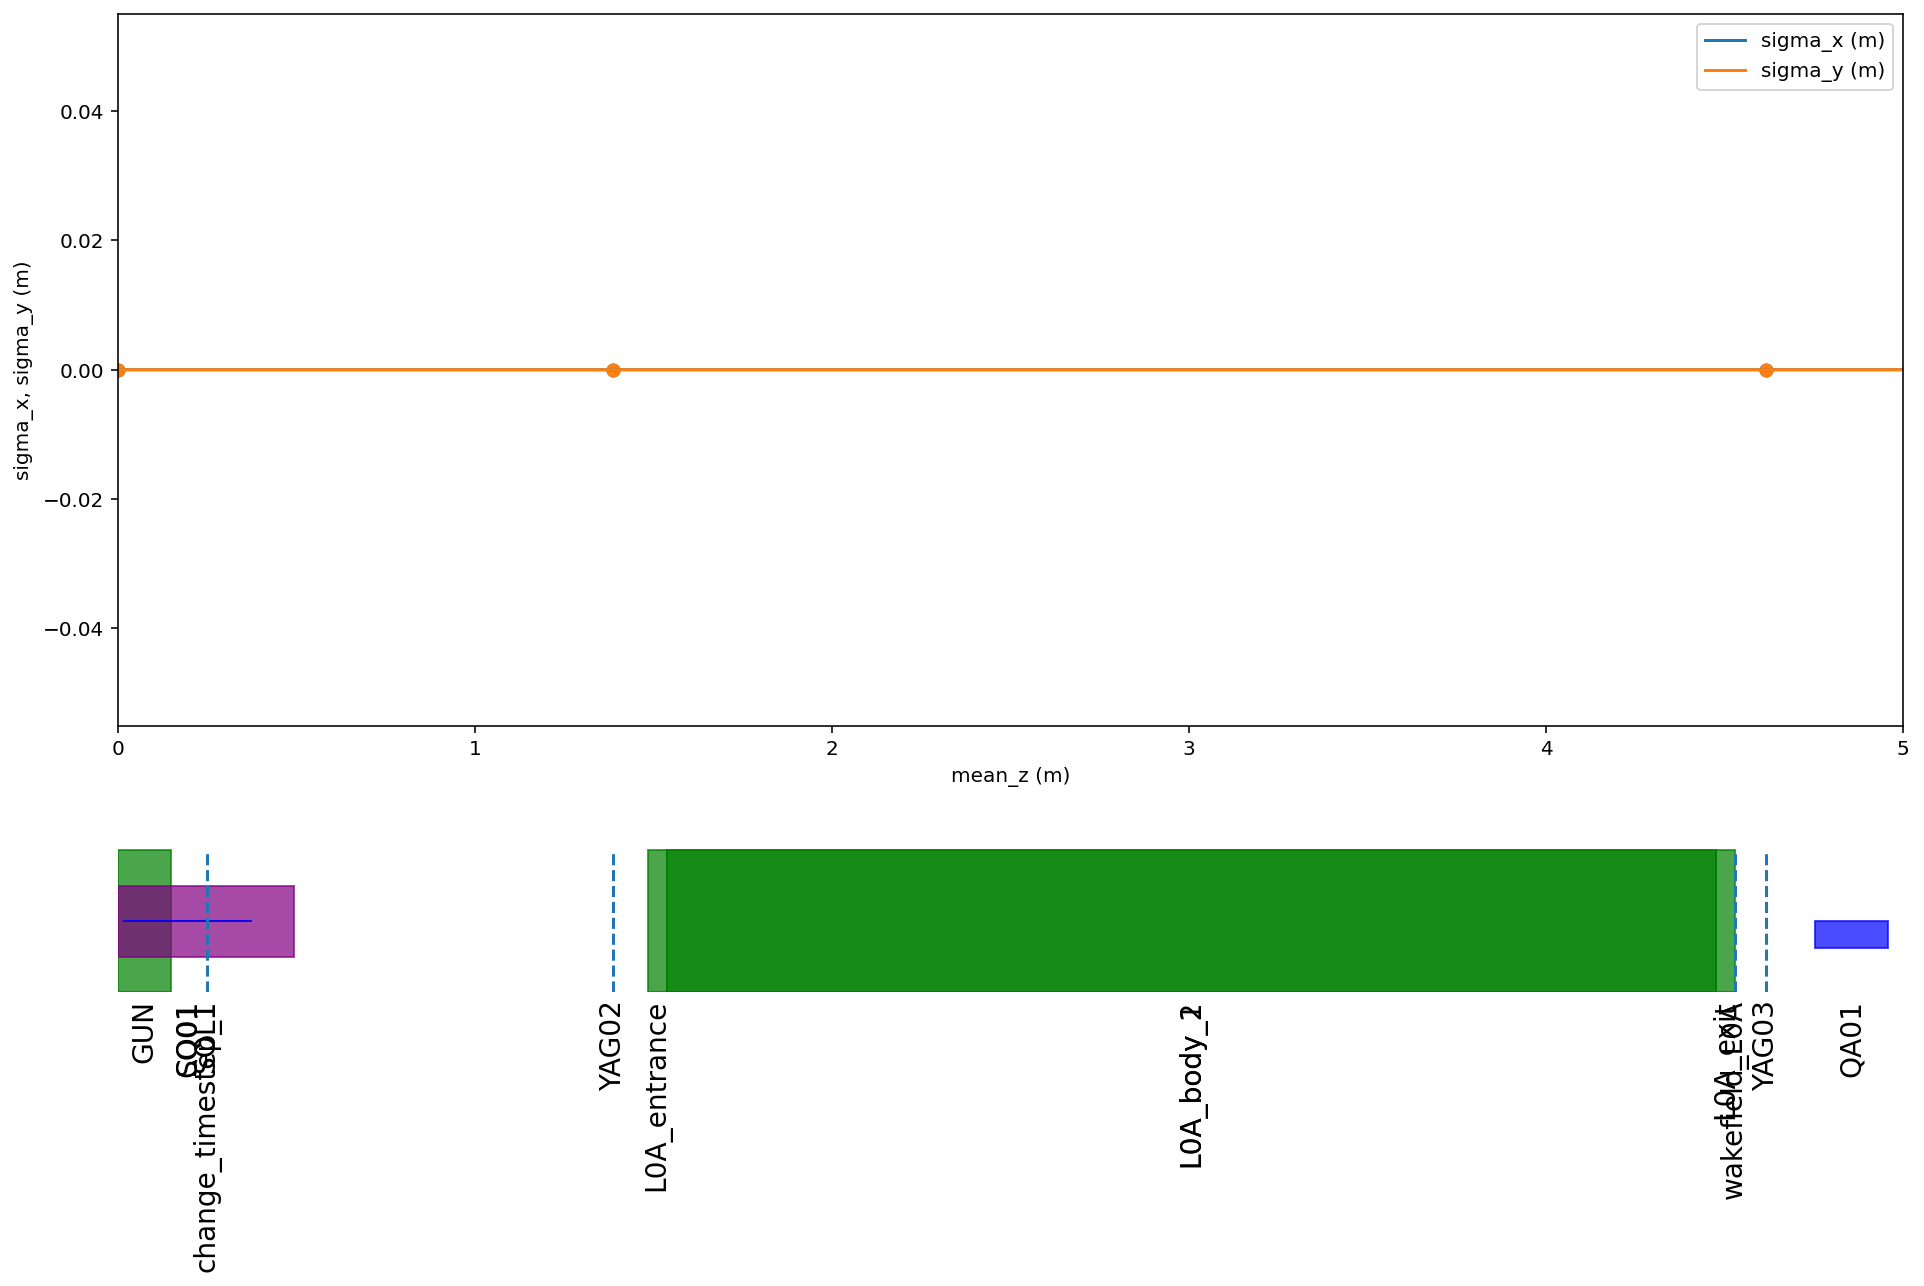

In [24]:
fig = I.plot(return_figure=True, include_labels=True, xlim=(0,5), figsize=(16,9))

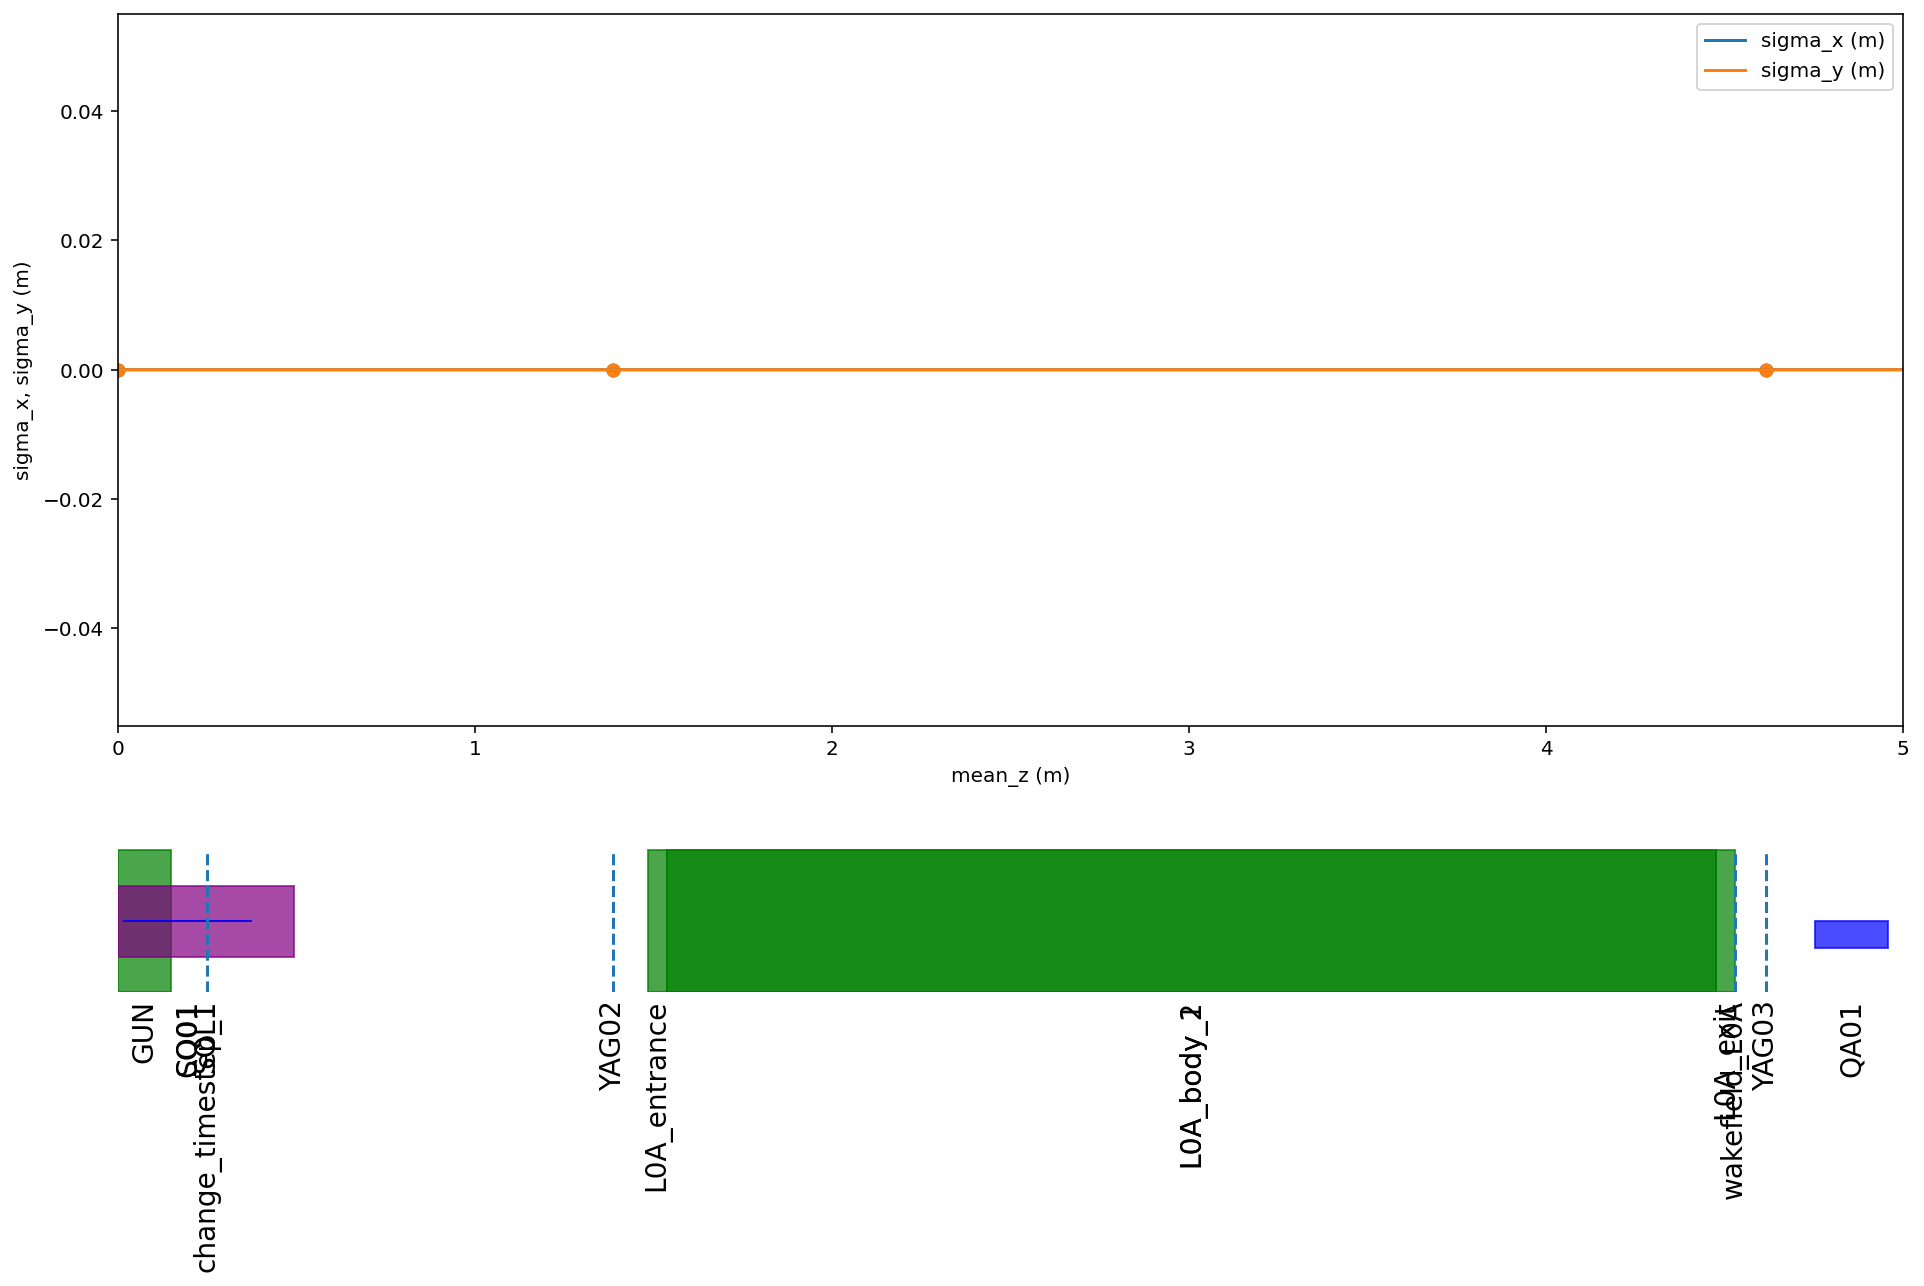

In [25]:
fig 

In [26]:
fig.savefig('test.pdf')

In [ ]:
plt.show()

In [ ]:
I['L0A_phase']['dtheta0_deg'] = 0

In [ ]:
I['L0A_entrance']

In [ ]:
for ele in I.lattice:
    if ele['type'] != 'quadrupole':
        continue
    name = ele['name']
    L = ele['L']
    L_eff = ele['L_effective']
    zedge = ele['zedge']
    sbeg = zedge + (L-L_eff)/2
    send = zedge + L - (L-L_eff)/2
    offset = 2017.91148
    print(f'{name} {L:10} {L_eff:10} {sbeg:10.6} {send:10.6}')

In [ ]:
from impact.lattice import ele_line
ele_line(I.lattice[-1])

# Check Energies

In [ ]:
from impact.autophase import autophase_and_scale

from pmd_beamphysics import single_particle

P0 = single_particle(pz=1e-15, z=1e-15)

# Energy out of the gun
I.track(P0, s = 0.5)['mean_energy']

In [ ]:
I.track(P0, s = I['L0A_exit']['s'])['mean_energy']

In [ ]:
I.track(P0, s = I['OTR2']['s'])['mean_energy']

In [ ]:
I.plot('mean_kinetic_energy')

In [ ]:
I.particles

# Gun Phasing

In [ ]:
autophase_and_scale(I, phase_ele_name='GUN_phase', phase_attribute='dtheta0_deg', scale_ele_name='GUN_scale', scale_attribute='voltage', target=6e6, scale_range=(4e6, 6e6), metric='mean_energy', initial_particles=P0, verbose=True)

# L0A, L0B

In [ ]:
# L0A
autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=False)

In [ ]:
ps_f, Itest = autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=True)

In [ ]:
# Phases to try
ptry = np.linspace(-2, 2, 9)

# scales to try
sc = 58e6
res = np.array([ps_f(p, sc)/1e6 for p in ptry])
plt.plot(ptry, res, label=f'{sc/1e6:0.2f} MV')
plt.title('Final energy for various phases and scales')
plt.ylabel('Final energy (MeV)')
plt.xlabel('phase (deg)')
plt.legend()

In [ ]:
# Get scale/voltage factor
30048347.359377533/(64e6 - 6e6) * np.array( [0.86571945106805, 1, 1, 0.86571945106805])

In [ ]:
autophase_and_scale(I, phase_ele_name='L0B_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0B_scale', scale_attribute='voltage', target=135e6, scale_range=(50e6, 80e6), initial_particles=P0, verbose=True)

# Integrated Solenoid field

In [ ]:
from impact import  fieldmaps
import numpy as np

# Fieldmaps are stored here
I.input['fieldmaps'].keys()

In [ ]:
# Look at a solrf element. 
I.ele['SOL1']

In [ ]:
# That data is here. 
rdfata = I.input['fieldmaps']['rfdata102']

#This will process the fieldmap to extract Ez and Bz
fmap = fieldmaps.process_fieldmap_solrf(rdfata['data'])
fmap

In [ ]:
# Reconstruction function
fieldmaps.fieldmap_reconsruction(fmap['Bz'], 0)

In [ ]:
zmax = 0.49308

zlist = np.linspace(0, zmax, 1000)
fieldlist = [fieldmaps.fieldmap_reconsruction(fmap['Bz'], z) for z in zlist]

# z at max field
zlist[np.argmax(np.array(fieldlist))]

In [ ]:
plt.plot(zlist, fieldlist)

In [ ]:
# Integrated field (approximate)
dz = zmax/1000
BL = np.sum(fieldlist)*dz  # T*m

# 
BL * 10 # T*m -> kG*m

In [ ]:
# Factor to convert BL in kG*m to Bmax in T
1/(BL * 10 )

# Corrector Quads

In [ ]:
ele = I.ele['CQ01']
ele

In [ ]:
I['CQ01:b1_gradient']

In [ ]:
# Factor to convert kG to T/m
0.1/ele['L_effective'] 